In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# Which product Sub-Categories experience the sharpest drop in profit margins when a discount is applied?

In [5]:
sales_profit_avgdiscount_by_subcat_discount = df.groupby(
    [
        df['Sub-Category'].rename('sub_category'),
        df['Discount'].rename('discount'),
    ]
)[
    [
        'Sales',
        'Profit',
        'Discount'
    ]
].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum')
).round(2)
sales_profit_avgdiscount_by_subcat_discount

total_sales  total_profit
sub_category discount                           
Accessories  0.00        556973.53     148249.59
             0.10         50650.75       9059.68
             0.20         54739.86       7141.61
             0.40         26458.81      -5928.75
             0.45          6140.62      -2195.88
...                            ...           ...
Unknown      0.50          6339.42      -3932.32
             0.57           794.36       -609.64
             0.60          2941.97      -2629.49
             0.70          2486.08      -3364.86
             0.80           151.64       -443.01

[204 rows x 2 columns]

In [8]:
sales_profit_avgdiscount_by_subcat_discount['profit_margin'] = (sales_profit_avgdiscount_by_subcat_discount['total_sales'] / sales_profit_avgdiscount_by_subcat_discount['total_profit']).round(2)

In [12]:
sales_profit_avgdiscount_by_subcat_discount.sort_values(by='profit_margin').head(10)

,,total_sales,total_profit,profit_margin
sub_category,discount,,,
Chairs,0.27,62387.78,-1338.27,-46.62
Unknown,0.32,204.67,-6.02,-34.00
Storage,0.20,76192.79,-2799.61,-27.22
Unknown,0.07,2991.10,-128.75,-23.23
Machines,0.25,13735.98,-900.70,-15.25
Art,0.27,8747.01,-603.75,-14.49
Chairs,0.30,68427.93,-6597.55,-10.37
Bookcases,0.35,18672.34,-2115.23,-8.83
Tables,0.30,103975.44,-11814.74,-8.80


In [28]:
sales_profit_avgdiscount_by_subcat_discount.reset_index(inplace=True)
sales_profit_avgdiscount_by_subcat_discount

,index,sub_category,discount,total_sales,total_profit,profit_margin
0,0,Accessories,0,556973.53,148249.59,3.76
1,1,Accessories,10,50650.75,9059.68,5.59
2,2,Accessories,20,54739.86,7141.61,7.66
3,3,Accessories,40,26458.81,-5928.75,-4.46
4,4,Accessories,45,6140.62,-2195.88,-2.80
...,...,...,...,...,...,...
199,199,Unknown,50,6339.42,-3932.32,-1.61
200,200,Unknown,56,794.36,-609.64,-1.30
201,201,Unknown,60,2941.97,-2629.49,-1.12
202,202,Unknown,70,2486.08,-3364.86,-0.74


In [27]:
sales_profit_avgdiscount_by_subcat_discount['discount'] = (sales_profit_avgdiscount_by_subcat_discount['discount'] * 100).astype(int)

In [29]:
sales_profit_avgdiscount_by_subcat_discount['discount'] = sales_profit_avgdiscount_by_subcat_discount['discount'].astype(str)

In [32]:
sales_profit_avgdiscount_by_subcat_discount['subcat_disc'] = sales_profit_avgdiscount_by_subcat_discount['sub_category'] + ' (' + sales_profit_avgdiscount_by_subcat_discount['discount'] + ')'

In [35]:
sales_profit_avgdiscount_by_subcat_discount.drop(columns='index',inplace=True)

In [36]:
sales_profit_avgdiscount_by_subcat_discount

,sub_category,discount,total_sales,total_profit,profit_margin,subcat_disc
0,Accessories,0,556973.53,148249.59,3.76,Accessories (0)
1,Accessories,10,50650.75,9059.68,5.59,Accessories (10)
2,Accessories,20,54739.86,7141.61,7.66,Accessories (20)
3,Accessories,40,26458.81,-5928.75,-4.46,Accessories (40)
4,Accessories,45,6140.62,-2195.88,-2.80,Accessories (45)
...,...,...,...,...,...,...
199,Unknown,50,6339.42,-3932.32,-1.61,Unknown (50)
200,Unknown,56,794.36,-609.64,-1.30,Unknown (56)
201,Unknown,60,2941.97,-2629.49,-1.12,Unknown (60)
202,Unknown,70,2486.08,-3364.86,-0.74,Unknown (70)


In [41]:
sales_profit_avgdiscount_by_subcat_discount.sort_values(by='profit_margin')

,sub_category,discount,total_sales,total_profit,profit_margin,subcat_disc
57,Chairs,27,62387.78,-1338.27,-46.62,Chairs (27)
193,Unknown,32,204.67,-6.02,-34.00,Other (32)
152,Storage,20,76192.79,-2799.61,-27.22,Storage (20)
185,Unknown,7,2991.10,-128.75,-23.23,Other (7)
121,Machines,25,13735.98,-900.70,-15.25,Machines (25)
...,...,...,...,...,...,...
171,Tables,20,154361.44,6298.39,24.51,Tables (20)
11,Appliances,15,18144.17,673.84,26.93,Appliances (15)
56,Chairs,25,37674.74,1083.78,34.76,Chairs (25)
99,Furnishings,27,15935.49,337.55,47.21,Furnishings (27)


In [40]:
sales_profit_avgdiscount_by_subcat_discount['subcat_disc'] = sales_profit_avgdiscount_by_subcat_discount['subcat_disc'].str.replace(r'Unknown','Other',regex=True)

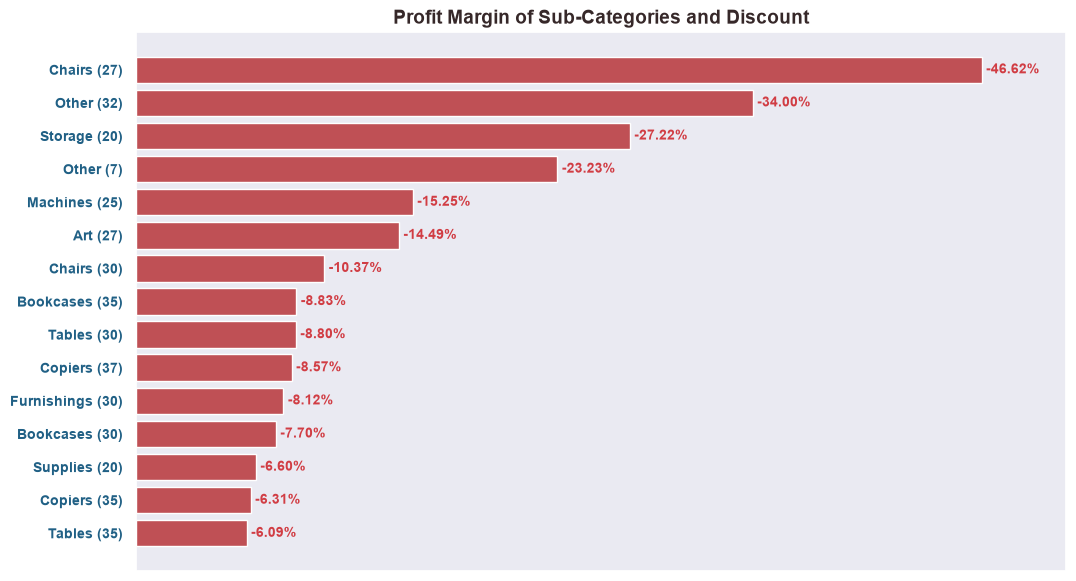

In [89]:
sns.set_theme()

figure, ax = plt.subplots(figsize=(12,7))

ax = sns.barplot(
    data=sales_profit_avgdiscount_by_subcat_discount.sort_values(by='profit_margin').head(15),
    x='profit_margin',
    y='subcat_disc',
    color='#D13D44'
)
ax.grid(False)
ax.margins(x=0.1, y=0.05)
ax.invert_xaxis() # invert x-axis
ax.set_title('Profit Margin of Sub-Categories and Discount', fontweight='bold', fontsize='14', color='#362829')
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_ylabel('')
ax.tick_params(labelsize=10, labelcolor='#206085')
for yticklabel in ax.get_yticklabels():
    yticklabel.set_weight('bold')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, color='#D13D44', fontweight='bold', fmt='{:,.2f}%')

In [90]:
# Business Question 15:
# Which product Sub-Categories experience the sharpest drop in profit margins when a discount is applied?

# Answer:
# This chart displays the top15 sub-categories that hit a tremendoush losses in profit margin. Under the Sub-Category, Chairs with 27% discount
# massively take the reduction in profit margin of 46%. Next to Chairs is Other sub-category with decrease of 34% in profit margin.
# Tables with 35% bump a 6% dump on its profit margin, it may not look incredibly bad with others but still a needs recabliration of discount.